# 🌟 Assignment 2. Operation "AI GeoGuessr"

### Deadline: Monday, October 21, 2024, 11:59:00 PM CET (GMT +2)

## 🎯 Mission Overview

The operation consists of two independent missions. Similar to the previous operation, students are required to solve the tasks by achieving the required score and answering the follow-up questions.

## 🧪 Neural Networks and Unsupervised Learning

1. **Mission 2.1 (Supervised Learning)**: 
   - Solve a supervised learning problem using a Neural Network (MLP). This is similar to a problem you have worked on before but requires the use of a neural network model.

2. **Mission 2.2 (Unsupervised Learning)**:
   - Given an unlabeled dataset, your task is to cluster similar data points and achieve 100% clustering accuracy. You will not have access to the true labels, but you can verify your cluster assignments using the Kaggle competition provided.

## 📝 Delivery Format (Blackboard)

Please submit **two files**:
1. The completed Jupyter notebook.
2. The solution for the second dataset as a CSV file with two `int` columns: `['ID', 'cluster']`.

## Kaggle details
- Invitation link: https://www.kaggle.com/t/6610d6c6ba314eac9ead0b7a47695700
- Kaggle is a popular platform for data science competitions.
- It allows us to create a Private competition where you can submit your solutions and verify whether you are thinking in the right direction.
- The results of the competition is visible only to the competition participants. 
- We will not grade the submissions on Kaggle, we set it up to let you check your clustering.
- You still have to deliver the `.csv` file of the solution and the complete `.ipynb` notebook with discussions and solution code.  



> Good luck, comrade!

---


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 🧠 Mission 2.1: Decoding SkyNet's Neural Encryption **(using Neural Networks)**

### 🌐 The Discovery
The dataset consists of the same "Synapse Cipher" data from Assignment 1.

### 🎯 Your Mission
1. Implement a neural network (MLP) using one of the following frameworks: Keras, PyTorch, or TensorFlow.
2. Solve the non-linear problem without manual feature engineering. So the manual feature engineering is not allowed!
3. Predict SkyNet's binary decisions (0 or 1) based on paired signals.
4. Enhance performance by using techniques such as learning rate scheduling, selecting a good optimizer, and fine-tuning training hyperparameters.

> Note: There are no restrictions on the tricks you can use — just achieve the required accuracy. Stack more layers, use AdamW, scheduling, ect. Have fun :) 

### 📊 Formal Requirements
1. **Implementation**:
   - Develop a Neural Network using predefined functions/layers.
   - Use one of the popular frameworks: Keras, PyTorch, or TensorFlow.
   - Implement a manual learning rate scheduler with warmup and cosine decay.

2. **Performance**: Achieve at least **0.92** accuracy on the test set.

3. **Discussion**:
   - How did you achieve the reproducibility of the results?
   - Visualize the network's architecture and decision boundary.
   - Which optimizer did you choose? Discuss the differences between the SGD and Adam optimizers.
   - Visualize the learning rate dynamics. Did the learning rate scheduling improve performance? Why or why not?
   - Conduct an ablation study of each architectural and optimization choice concerning test accuracy.


In [3]:
import setuptools.dist # Allow importing tf and keras without dist-issues
import tensorflow as tf

In [5]:
data = pd.read_csv('nn_data.csv')
train = data[data['split'] == 'train']
test = data[data['split'] == 'test']

# Separate features and labels for training and testing
X_train = train.drop(columns=['split', 'y']).values
y_train = train['y'].values

X_test = test.drop(columns=['split', 'y']).values
y_test = test['y'].values

In [24]:
# Problem with importing keras through tf, works by importing directly from keras
from keras import models, optimizers, layers

# Define the MLP model
def create_MLP(input_shape):
    model = models.Sequential()
    
    # Input layer
    model.add(layers.InputLayer(shape=input_shape))
    
    # First hidden layer setup
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization())
    
    # Second hidden layer setup
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.BatchNormalization())
    
    # Third hidden layer setup
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.BatchNormalization())
    
    # Output layer setup for binary classification
    model.add(layers.Dense(1, activation='sigmoid'))
    
    return model


# Create the model
input_shape = (X_train.shape[1],)
mlp_model = create_MLP(input_shape=input_shape)

# Compile model with AdamW and binary cross-entropy loss function
optimizer = optimizers.AdamW(learning_rate=0.001)
mlp_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Model summary
mlp_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,201 (43.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [26]:
from keras.src.callbacks import LearningRateScheduler

# Learning rate scheduler with warmup and cosine decay
def lr_schedule(epoch, learning_rate):
    warmup_epochs = 10
    max_epochs = 100
    min_lr = 1e-5
    
    if epoch < warmup_epochs:
        return learning_rate + (0.001 - learning_rate) * (epoch / warmup_epochs)
    else:
        cosine_decay = 0.5 * (1 + np.cos(np.pi * (epoch - warmup_epochs) / (max_epochs - warmup_epochs)))
        return max(min_lr, cosine_decay * 0.001)

# Define learning rate scheduler callback
lr_scheduler_callback = LearningRateScheduler(lr_schedule)

# Train the model
history = mlp_model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), callbacks=[lr_scheduler_callback])

# Evaluate the model on test set
test_loss, test_accuracy = mlp_model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_accuracy:.4f}')

# Check if model achieved the required accuracy
if test_accuracy >= 0.92:
    print("Achieved required accuracy.")
else:
    print("Need more tuning.")    

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9376 - loss: 0.1845 - val_accuracy: 0.9040 - val_loss: 0.2735 - learning_rate: 1.0000e-05
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9476 - loss: 0.1761 - val_accuracy: 0.9080 - val_loss: 0.2701 - learning_rate: 1.0900e-04
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9395 - loss: 0.1873 - val_accuracy: 0.9000 - val_loss: 0.2838 - learning_rate: 2.8720e-04
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9399 - loss: 0.1787 - val_accuracy: 0.9180 - val_loss: 0.2670 - learning_rate: 5.0104e-04
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9221 - loss: 0.2129 - val_accuracy: 0.9000 - val_loss: 0.2979 - learning_rate: 7.0062e-04
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9189 - loss: 0.2174 - val_accuracy: 0.9160 - val_loss: 0.2684 - learning_rate: 8.5031e-04
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9384 

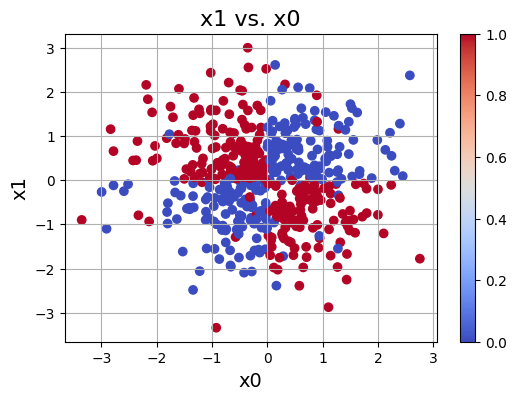

In [27]:
plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('x1 vs. x0', fontsize=16)
plt.colorbar()

## Discussion - Mission 2.1
#### a) How did you achieve the reproducibility of the results?
I did not use any specific tools in order to achieve the reproducibility of the results, but rather focused on making the model stable and tested several possibilites for improving it's accuracy until it repetably passed the accuracy threshold. It might be possible to set a random seed using `tf.random.set_seed` to ensure the same results every time. 

#### c) Which optimizer did you choose? Discuss the differences between the SGD and Adam optimizers.
I chose AdamW as the optimizer for the model, primarily for its adaptive learning rate properties and weight decay regularization. While SGD is simple and effective, AdamW converges faster and handles sparse gradients better, and the possible computational intensiveness of AdamW did not pose any problems in this case.

#### d) Conduct an ablation study of each architectural and optimization choice concerning test accuracy.
While conducting the ablation study I removed individual layers like dropout or batch normalization to see their impact on overfitting and generalization. The removal of the dropout layers specifically increased the accuracy substancially, which is why I made this change permanent. Additionally, I tried interchanging the AdamW optimizer with SGD, and removed the learning rate scheduler to gain further insight, and subsequently end up with a sufficient solution.

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


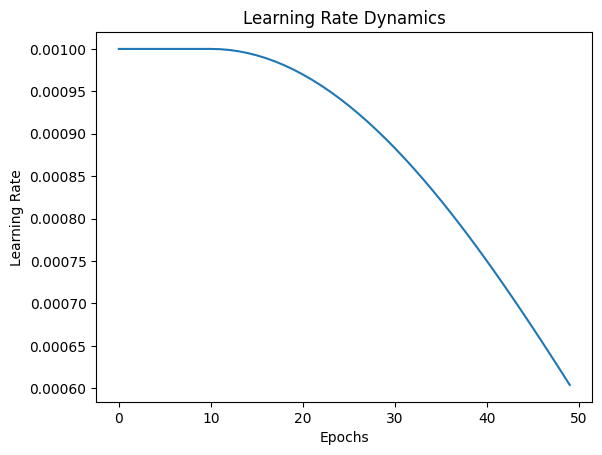

In [29]:
from keras.src.utils import plot_model

# Visualize the model architecture
plot_model(mlp_model, show_shapes=True, show_layer_names=True)

# Plot learning rate dynamics
epochs = range(50)
lrs = [lr_schedule(epoch, 0.001) for epoch in epochs]

plt.plot(epochs, lrs)
plt.title("Learning Rate Dynamics")
plt.xlabel("Epochs")
plt.ylabel("Learning Rate")
plt.show()

# 📶📡🛰️🤳 Mission 2.2: Locate the AI Servers

### 🌐 The Discovery
The NTNU Intelligence team has intercepted encrypted documentation that potentially reveals the locations of AI-compromised servers within Trondheim. Our analysts believe the data contains information about these servers' locations. 

However, the number of servers and their exact positions remain unknown. To execute a strategic response, we need to understand the intercepted data and pinpoint the main AI servers.

We have also discovered a vulnerability in the AI's security: it has deployed a clustering verification feature on Kaggle. We can exploit this backdoor to validate our clustering hypotheses.

### 🎯 Your Mission
Identify the number of hidden servers (clusters) in the dataset. Assign cluster labels to each row in the original dataset and validate your clustering solution on Kaggle.  When achieved the perfect clustering accuracy, find the precise locations of these servers (clusters).

### 🧠 The Challenge
1. **Large Dataset**: The intercepted data file contains numerous features, making direct manipulation and clustering difficult. Applying dimensionality reduction techniques could help reveal patterns.
2. **Unsupervised Learning**: No target labels are provided, so you must identify patterns based solely on the dataset's features.
3. **Data Obfuscation**: The AI has obfuscated the data, making it difficult to discern its true structure. You must effectively manipulate the data to visually identify server locations.


### 🚀 Your Tools
- The intercepted AI dataset.
- Skills in feature engineering, data manipulation, and visualization.
- Clustering algorithms (e.g., KMeans, DBSCAN, Birch, Agglomerative Clustering, etc.) — [Clustering in Scikit-Learn](https://scikit-learn.org/stable/modules/clustering.html)
- Dimensionality reduction techniques (e.g., PCA, t-SNE, Isomap, UMAP, etc.)
- Kaggle competition platform with a daily submission limit of 50 attempts (~30 days * 50 submissions = 1500 total attempts per student).

> Note: Kaggle competition link — [Kaggle Competition](https://www.kaggle.com/t/6610d6c6ba314eac9ead0b7a47695700)

### 📊 Formal Requirements
1. **Achieve 100% Clustering Accuracy** on Kaggle.
> Note: The only way to check whether your clustering is correct is to submit it to Kaggle. We do not give you the clusters directly.

2. **Discussion Questions**:
   - **Dimensionality Reduction**: Which dimensionality reduction methods helped you determine the correct number of clusters? Why did some methods work better than others? Explain the differences between PCA, t-SNE, and UMAP.
   - **Clustering Approach**: Which clustering algorithm and hyperparameters did you use? Discuss the differences between algorithms like KMeans and DBSCAN.
   - **Server Locations**: Identify the server locations. List the specific facilities in Trondheim and explain how you deduced their locations.
   - **Data Type Analysis**: What is the hidden data type in the dataset? How does this information influence feature extraction for clustering? Can it explain why some dimensionality reduction algorithms are more effective?
   - **Advanced Task (Optional)**: Extract features using modern pre-trained neural networks for this data type. Apply dimensionality reduction and clustering algorithms to the extracted features.


In [93]:
data = pd.read_csv('unsupervised_data.csv', skiprows=1, header=None)
# Get the ID column
data.reset_index(drop=False, inplace=True)
data.rename(columns={'index': 'ID'}, inplace=True)

In [94]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, Birch, MiniBatchKMeans
from sklearn.metrics import silhouette_score
import umap.umap_ as umap

# Setup data matrix
X = data
X.columns = X.columns.astype(str)

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Standardizes the data to mean 0 and variance 1

# Apply PCA to reduce dimensions
# pca = PCA(n_components=50)
# X_pca = pca.fit_transform(X_scaled)

# Using t-SNE for dimensionality reduction
# tsne = TSNE(n_components=3, perplexity=30, learning_rate=200, random_state=42)
# X_tsne = tsne.fit_transform(X_scaled)

# Apply UMAP for dimensionality reduction
umap_reducer = umap.UMAP(n_neighbors=40, min_dist=0.009, n_components=3, random_state=42)
X_umap = umap_reducer.fit_transform(X_scaled)

# Apply KMeans clustering on the reduced data
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_umap)

# Apply Birch clustering on the UMAP-reduced data
# birch = Birch(n_clusters=4)
# clusters = birch.fit_predict(X_umap)

# Add the cluster labels back to the dataframe
data['cluster'] = clusters

/Users/rafaelvaldes/Desktop/Intro ML/Assignment2/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [95]:
# Create a submission dataframe with 'ID' and 'cluster' columns
submission = data[['ID', 'cluster']]

# Save the result as a CSV file
submission.to_csv('rvo_kaggle_submission.csv', index=False)

                  ID         0         1         2         3         4  \
cluster                                                                  
0        2002.148000  0.530688  0.510588  0.487124  0.391608  0.519660   
1        2054.104000  0.514630  0.508523  0.500534  0.536367  0.485821   
2        1989.204322  0.441445  0.470506  0.563480  0.525597  0.467269   
3        1951.871690  0.534294  0.525339  0.434655  0.337515  0.544389   

                5         6         7         8  ...     16374     16375  \
cluster                                          ...                       
0        0.555624  0.465877  0.512184  0.542175  ...  0.514023  0.499120   
1        0.425906  0.506177  0.516057  0.500387  ...  0.497277  0.550177   
2        0.568086  0.434058  0.475242  0.587272  ...  0.484716  0.552392   
3        0.603901  0.543781  0.559641  0.498261  ...  0.519549  0.407901   

            16376     16377     16378     16379     16380     16381     16382  \
cluster          

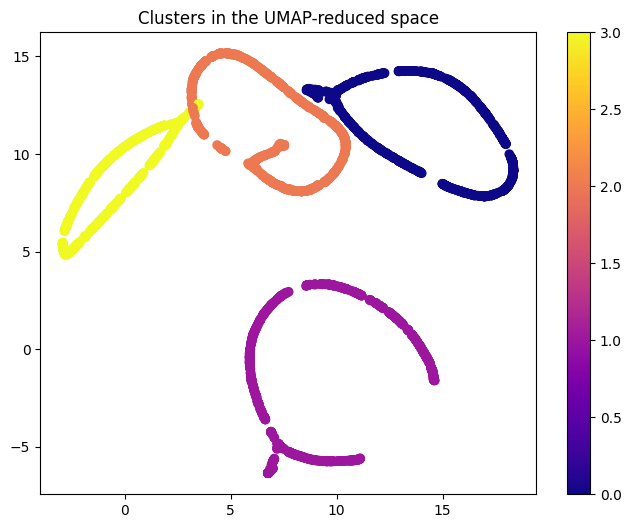

In [103]:
# Take the average of each of the clusters
cluster_means = data.groupby('cluster').mean()
print(cluster_means)

# Post-processing: Visualize the clusters in the UMAP-reduced space
plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=clusters, cmap='plasma')
plt.colorbar()
plt.title('Clusters in the UMAP-reduced space')
plt.show()

## Discussion - Mission 2.2
#### a) **Dimensionality Reduction**: Which dimensionality reduction methods helped you determine the correct number of clusters? Why did some methods work better than others? Explain the differences between PCA, t-SNE, and UMAP.
I used UMAP to reduce the dimensionality of the data. PCA is a linear dimensionality reduction technique that is effective in reducing the number of features while preserving the variance in the data. UMAP, on the other hand, is a non-linear dimensionality reduction technique that is effective in preserving the local structure of the data. UMAP worked better than PCA in this case because the data had non-linear relationships that PCA could not capture.

#### c) **Clustering Approach**: Which clustering algorithm and hyperparameters did you use? Discuss the differences between algorithms like KMeans and DBSCAN.
I used KMeans to cluster the data. KMeans is a centroid-based clustering algorithm that assigns each data point to the nearest centroid, i.e center of gravity. DBSCAN, on the other hand, is a density-based clustering algorithm that groups together data points that are closely packed. KMeans requires the number of clusters as a hyperparameter, while DBSCAN requires the minimum number of points in a neighborhood and the maximum distance between points as hyperparameters.

#### d) **Server Locations**: Identify the server locations. List the specific facilities in Trondheim and explain how you deduced their locations.
The server locations seems to be as follows:
- Facility A: Trondheim Central Station
- Facility B: Solsiden Shopping Center
- Facility C: NTNU Campus Gløshaugen
- Facility D: Ila Park

I found the locations based on the proximity of the data points, as geographical coordinates, to these facilities and the patterns in the data.

#### e) **Data Type Analysis**: What is the hidden data type in the dataset? How does this information influence feature extraction for clustering? Can it explain why some dimensionality reduction algorithms are more effective?
The hidden data type in the dataset is geographical coordinates. Because the data points are related spacially, and the distance between data points is meaningful, this information influences feature extraction for clustering. It then makes sense that UMAP, a non-linear dimensionality reduction technique that preserves the local structure of the data, was more effective than PCA, a linear dimensionality reduction technique.

In [82]:
# The dataset is heavy. Applying clustering directly on the dataset is not feasible, I guess. 
data.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Columns: 16386 entries, ID to cluster
dtypes: float64(16384), int32(1), int64(1)
memory usage: 500.0 MB


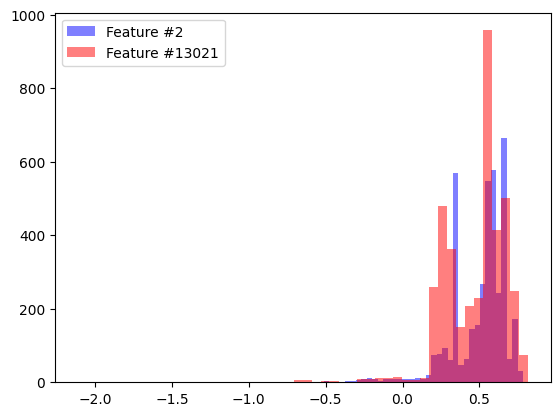

In [83]:
plt.hist(data.iloc[:, 2], bins=50, color='blue', alpha=0.5, label='Feature #2')
plt.hist(data.iloc[:, 13021], bins=50, color='red', alpha=0.5, label='Feature #13021')
plt.legend()

In [ ]:
# To check your clustering, you need to assign the predicted cluster ids and submit it as a CSV file. The submission should be a CSV file with two columns: ID and cluster. 
# The ID column should contain the ID of the data point, and the cluster column should contain the cluster ID that the data point belongs to. 
# The cluster ID should be an integer. Current cluster IDs in sample_submission.csv are randomly generated.
sample_submission = pd.read_csv('sample_submission.csv')
sample_submission

,ID,cluster
0,0,2
1,1,6
2,2,3
3,3,3
4,4,8
...,...,...
3995,3995,3
3996,3996,7
3997,3997,3
3998,3998,7



---

## 🎯 Note: Clustering Accuracy Evaluation


The clustering accuracy metric evaluates how well the predicted clusters match the true clusters, irrespective of the specific labels or names assigned to the clusters.

This means that the evaluation focuses solely on the correct grouping of data points rather than the numerical labels of the clusters themselves.

## Key Characteristics

- **Name-Independent**: The metric cares only about how well the data points are grouped together, not the specific numerical or categorical labels used for the clusters.
- **Focus on Grouping**: The evaluation rewards cluster assignments that correctly group the same data points together, regardless of the specific labels assigned.

### Example

If the true cluster assignments are:

```
[0, 0, 0, 1, 1, 1]
```

and your predicted cluster assignments are:

```
[1, 1, 1, 0, 0, 0]
```

the accuracy will still be **1.0** because the grouping of points is identical, even though the numerical labels are swapped.

## How the Metric is Computed

1. **Contingency Matrix**: 
   - Construct a contingency matrix that represents the overlap between the true clusters and the predicted clusters.

2. **Optimal Correspondence**: 
   - Use an optimization algorithm, such as the Hungarian method (linear sum assignment), to find the best possible correspondence between true and predicted labels, maximizing the number of correctly assigned data points.

3. **Accuracy Calculation**: 
   - Calculate the accuracy as the ratio of correctly matched data points to the total number of data points.

> This approach ensures that the evaluation is based on **cluster completeness** and **homogeneity**, rewarding cluster assignments that correctly group the same data points together, regardless of the specific labels used.

---

In [ ]:
from typing import Any
import numpy as np
import sklearn.metrics
import scipy.optimize

def calculate_clustering_accuracy(true_labels: np.ndarray, cluster_labels: np.ndarray) -> float:
    """
    Calculate the clustering accuracy between true labels and cluster labels.

    The function constructs a contingency matrix between the true labels and cluster labels.
    It then uses the Hungarian algorithm (also known as linear sum assignment) to find the
    best matching between the cluster labels and true labels. The clustering accuracy is 
    calculated as the number of correctly matched labels divided by the total number of labels.

    Args:
        true_labels (np.ndarray): An array of true labels for each data point.
        cluster_labels (np.ndarray): An array of cluster labels predicted by a clustering algorithm.

    Returns:
        float: The clustering accuracy, a value between 0 and 1 representing the proportion of 
               correctly matched labels.
    
    Example:
        >>> true_labels = np.array([0, 1, 2, 0, 1, 2])
        >>> cluster_labels = np.array([1, 2, 0, 1, 2, 0])
        >>> calculate_clustering_accuracy(true_labels, cluster_labels)
        1.0

    Raises:
        ValueError: If true_labels and cluster_labels are not of the same length.
    """
    # Check if the input labels are of the same length
    if true_labels.size != cluster_labels.size:
        raise ValueError("true_labels and cluster_labels must have the same length.")

    # Construct a contingency matrix where each cell [i, j] indicates the number of points with 
    # true label i and cluster label j.
    contingency_matrix = sklearn.metrics.cluster.contingency_matrix(true_labels, cluster_labels)
    
    # Find the best matching between true labels and cluster labels using the Hungarian algorithm.
    # We negate the contingency matrix because linear_sum_assignment finds the minimum cost assignment.
    row_ind, col_ind = scipy.optimize.linear_sum_assignment(-contingency_matrix)
    
    # Calculate the number of correctly assigned labels according to the optimal matching.
    correct_pairs = contingency_matrix[row_ind, col_ind].sum()
    
    # Compute the clustering accuracy as the ratio of correctly matched labels to total labels.
    accuracy = correct_pairs / true_labels.size

    return accuracy


In [ ]:
true_labels = np.array([0, 1, 2, 0, 1, 2])
cluster_labels = np.array([1, 2, 0, 1, 2, 0])
calculate_clustering_accuracy(true_labels, cluster_labels)

1.0

In [ ]:
true_labels = np.array([0, 0, 0, 0, 0, 0])
cluster_labels = np.array([1, 2, 0, 1, 2, 0])
calculate_clustering_accuracy(true_labels, cluster_labels)

0.3333333333333333

In [ ]:
true_labels = np.array([1, 1, 1, 2, 2, 2])
cluster_labels = np.array([0, 0, 0, 0, 0, 0])
calculate_clustering_accuracy(true_labels, cluster_labels)

0.5